In [3]:
import pandas as pd        # for handling data (like Excel but in Python)
import numpy as np         # for numerical operations
import seaborn as sns      # for visual graphs
import matplotlib.pyplot as plt   # for plotting charts

from sklearn.model_selection import train_test_split    # splits data for training & testing
from sklearn.feature_extraction.text import TfidfVectorizer  # converts text into numbers
from sklearn.naive_bayes import MultinomialNB           # our ML model for text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

# Show first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename column names for clarity
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

# Check first rows
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isnull().sum()


,0
label,0
message,0


In [8]:
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [9]:
from sklearn.model_selection import train_test_split

X = df['message']       # features (input)
y = df['label_num']     # labels (output)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF object
tfidf = TfidfVectorizer(stop_words='english')

# Fit on training data and transform both sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [11]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)


MultinomialNB()

In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9668161434977578

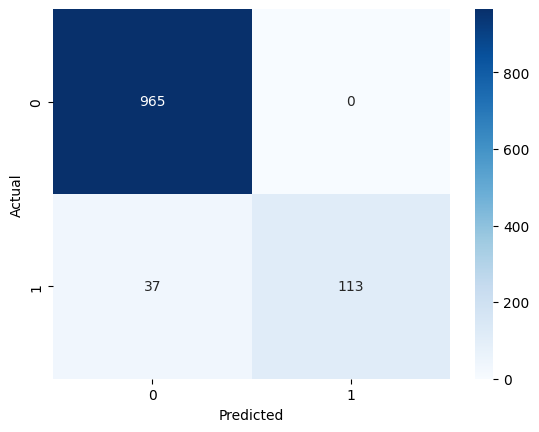

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
def predict_message(msg):
    msg_tfidf = tfidf.transform([msg])
    pred = model.predict(msg_tfidf)[0]
    return "SPAM" if pred == 1 else "HAM"

predict_message("You won 50000 rupees! Claim now!")

'SPAM'

In [15]:
predict_message("Bro class kitne baje hai")
predict_message("Free recharge click here")
predict_message("Your pizza is on the way")

'HAM'

In [16]:
import joblib

# Save the trained model
joblib.dump(model, "spam_model.pkl")

# Save the TF-IDF vectorizer also
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

"Model and vectorizer saved successfully!"

'Model and vectorizer saved successfully!'